# Figure 5B: Curriculum Schematics & Training Losses

06/05/2026

Plots P(Misaligned) over training for two curricula (`clean_early` (imbalanced), `static` (balanced)):
- **Top row**: Schematic of aligned/misaligned data fraction over training epochs
- **Bottom row**: Train and eval loss curves (mean ± ribbon across seeds)

Data loaded from `results/linear_interpolation_curriculum`.
Set `save_figures = True` to export SVGs to `figs/fig5/`.


In [2]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns
from importlib import reload
import os
from matplotlib.patches import Patch

import sys
sys.path.append('../../')

import src.datasets.DeonticEthicsDataset as deontic_utils
import src.plot_utils as plg
from src.plot_utils import format_axis, dataPal, curricula_names
from src.models import Transformer

In [3]:
fig5_path = 'figs/fig5'
os.makedirs(fig5_path, exist_ok=True)

save_figures = False

# Load data

In [4]:
## Load model and corpus
data_dir = "results/linear_interpolation_curriculum"

data_path_base = data_dir + "/static/"
data_path_base += [fl for fl in os.listdir(data_path_base) if '.DS' not in fl][0]

data_runs = os.listdir(data_path_base)
data_runs = [dr for dr in data_runs if ('.DS' not in dr) and ('evals' not in dr)]

# Config
with open(os.path.join(data_path_base,data_runs[0], "model_config_train.json")) as f:
    config = json.load(f)

# Params
with open(os.path.join(data_path_base,data_runs[0], "params.json")) as f:
    params = json.load(f)

datafile = params['data_path']

with open(datafile , 'r') as file:
    data = json.load(file)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'using device: {device}')



using device: mps


In [5]:
# find all corrpution levels
datapath = data_dir
curricula = ['clean_early', 'static']
curricula_order = ['clean_early', 'static']

## Define phases
loss_switches  = [config['epochs']]


## Compare Losses

In [6]:
losses = {}

for curr in tqdm(curricula):

    cdir = os.listdir(os.path.join(datapath, curr))
    cdir = [cc for cc in cdir if '.DS' not in cc]
    cpath = os.path.join(datapath, curr, cdir[0])

    dataruns = os.listdir(cpath)
    dataruns = [dt for dt in dataruns if ('evals' not in dt) and ('.DS' not in dt)]

    with open(os.path.join(cpath, dataruns[0], "model_config_train.json")) as f:
        config = json.load(f)
    switch_point  = config['epochs']

    losses[curr] = {k:[] for k in ['train_losses', 'eval_losses']}
    for run in dataruns:
        history = torch.load(os.path.join(cpath, run, "history.pt"), map_location=device)
        for k in ['train_losses', 'eval_losses']:
            losses[curr][k].append(np.vstack(history[k])[:,1])
        


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:13<00:00,  6.83s/it]


In [7]:
#### ------------------------------------------------------
#### Plotting functions for curricula schematics
#### ------------------------------------------------------

def linear_weight_interpolation(epoch, start=0.1, end=0.5, plateau=0.1, n_epochs=100):
    """
    Piecewise schedule: hold at `start` for an initial plateau, then linearly ramp to `end`.

    Args:
        epoch: Current epoch (0-based).
        start: Value during plateau.
        end: Final value at last epoch.
        plateau: Fraction of epochs at constant `start`.
        n_epochs: Total number of epochs.

    Returns:
        Interpolated value for this epoch.
    """
    if n_epochs <= 1:
        return end

    plateau_steps = int(round(n_epochs * plateau))
    plateau_steps = min(max(plateau_steps, 0), n_epochs - 1)

    if epoch < plateau_steps:
        return start

    ramp_steps = n_epochs - plateau_steps
    t = (epoch - plateau_steps) / max(ramp_steps - 1, 1)
    return start + (end - start) * t


def find_misaligned_end(start, plateau, corruption_level):
    """
    Solve for `end` so a plateau+linear schedule has a given average.

    Args:
        start: Plateau value.
        plateau: Fraction of training at plateau.
        corruption_level: Desired average value over training.

    Returns:
        End value of the linear ramp.
    """
    if plateau >= 1.0:
        return start
    return 2 * (corruption_level - plateau * start) / (1 - plateau) - start

################
##
###############


curricula_schematic = {
    curricula_names['clean_early']: {'start': 5, 'end':find_misaligned_end(5, 0.1, 40), 'plateau': 0.15},
    curricula_names['static']: {'start': 40, 'end':40, 'plateau': 0},
             }

n_epochs = 100 
n_epochs_total = 2.5*n_epochs


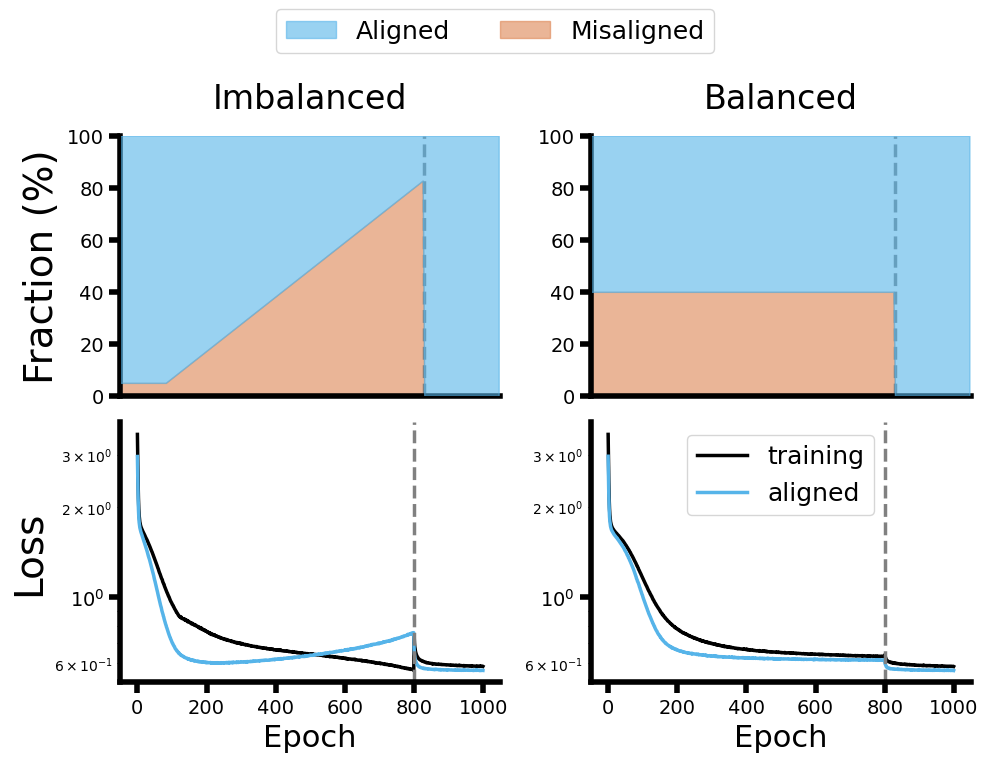

In [8]:
## plot

fig, axs = plt.subplots(2, len(curricula), figsize = (len(curricula)*5, 3.5*2))

x = np.arange(250)
for ci, curr in enumerate(curricula_schematic):

    ax=axs[0, ci]
    ax.set_xlim(0,250)
    ax.set_xticks([])
    ax.set_title(curr)
    
    curr_start, curr_end, curr_plateau =curricula_schematic[curr]['start'], curricula_schematic[curr]['end'],curricula_schematic[curr]['plateau']
    threshold = [linear_weight_interpolation(epoch, start=curr_start, end=curr_end, plateau =curr_plateau,  n_epochs=n_epochs*2) for epoch in range(n_epochs*2)]
    threshold = np.array(threshold + [0]*int(n_epochs_total - n_epochs*2))
    midpoint = (threshold + 100) / 2

    # Grey region (primary axis)
    ax.fill_between(x, 0, threshold, color=dataPal['misaligned'], alpha=0.6)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Epoch")
    ax.set_yticks(list(range(0, 101, 20)))

    # Second y-axis
    ax2 = ax.twinx()

    # Upper half of purple region: pale orange
    ax2.fill_between(x, threshold, 100, color=dataPal['aligned'], alpha=0.6)
    ax2.set_ylim(0, 100)
    ax2.set_yticks(ticks =[])
      
    for phase in [200]:
        ax.axvline(phase, linestyle = '--', color = 'grey')
    
    ax.set_xlabel('')
    format_axis(ax)

for ci, curr in enumerate(curricula_order):
    ax=axs[1, ci]
    for ki, k in enumerate(losses[curr]):
        plg.plot_ribbon(np.vstack(losses[curr][k]), color = [dataPal['training'], dataPal['aligned']][ki], label = ['training', 'aligned'][ki], 
                        ax=ax, linewidth=4)
    # ax.set_title(curr, fontsize = 24)
    ax.axvline(params['n_epochs'], linestyle = '--', color = 'grey')
    ax.set_xlabel('Epoch')
    format_axis(ax)
    ax.set_yscale('log')

legend_handles = [
    Patch(color=dataPal['aligned'], alpha=0.6, label='Aligned'),
    Patch(color=dataPal['misaligned'], alpha=0.6, label='Misaligned')]
# axs[0,0].legend(handles=legend_handles, loc='upper left', fontsize=18)
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols = 3,
           fontsize=18)

axs[1, -1].legend(fontsize=18)
axs[0,0].set_ylabel("Fraction (%)", fontsize = 28)
axs[1, 0].set_ylabel('Loss', fontsize = 28)
axs[1, 0].set_xlabel('Epoch', fontsize = 22)
axs[1, 1].set_xlabel('Epoch', fontsize = 22)

sns.despine()
fig.tight_layout()

if save_figures:
    plt.savefig(os.path.join(fig5_path, "curriculum_schematic.svg"), transparent=True, bbox_inches='tight', dpi=300)